# 🧺 Quick Basket Checkout App
### Automating Small Business Sales with Python

Welcome! In this notebook we will build a small, **offline-friendly checkout
system** that a small retailer (a provisions store, a boutique, a pharmacy,
etc.) can use to:

1. **Set up** the basic app structure (a "cart" to hold items)
2. **Collect** item names, prices and quantities from a cashier
3. **Calculate** the subtotal, apply a discount, and add tax (VAT)
4. **Generate** a clean, readable receipt
5. **Save the receipt as an image file** so it can be shared (e.g. on WhatsApp) or printed

This notebook is written for **beginners**. Every code cell is preceded by a
short explanation, and comments inside the code explain *why*, not just *what*.

> 💡 **Why "offline-friendly"?** Many small retailers don't have reliable
> internet. Everything here runs with Python's built-in tools plus one small
> image library (`Pillow`) — no internet connection or database server needed.


## Step 1 — Setup App Structure

Before writing any "logic", we decide **how our data will be shaped**.

Our checkout app is built around one central idea: the **cart**.

We store the cart as a Python **dictionary** (`dict`) because a dictionary
lets us look up information using a meaningful **key** instead of a numbered
position (like in a list). Here, the key is the *item name*, and the value is
another dictionary holding the *price* and *quantity*:

```python
cart = {
    "Bread": {"price": 900.0, "quantity": 2},
    "Rice":  {"price": 1500.0, "quantity": 3},
}
```

This is called a **nested dictionary** — a dictionary inside a dictionary.
It mirrors how a real cashier thinks: *"for each item, I need to remember its
price and how many the customer is buying."*

We also write two small **functions** — `add_item()` and `remove_item()` — so
the rest of our program never has to fiddle with the dictionary directly. This
is a core programming idea called **abstraction**: hide the messy details
inside a function with a clear name.


In [1]:
# ============================================================
# STEP 1: APP STRUCTURE
# ============================================================
from datetime import datetime  # built-in module for timestamps on receipts

# The cart is a dictionary: {item_name: {"price": ..., "quantity": ...}}
# Starting it as an empty dict means "no items yet".
cart = {}


def add_item(cart, name, price, quantity):
    """
    Add an item to the cart, or increase its quantity if it's already there.

    Parameters
    ----------
    cart : dict
        The shopping cart dictionary to update.
    name : str
        The item's name, e.g. "Bread".
    price : float
        Price per single unit, in Naira (₦).
    quantity : int
        How many units the customer is buying.

    Returns
    -------
    None. The cart dictionary is updated "in place" (this is why we don't
    need to `return cart` — dictionaries are mutable in Python).
    """
    # .strip() removes accidental spaces; .title() makes "bread" and "BREAD"
    # match "Bread" so we don't accidentally create two separate entries.
    name = name.strip().title()

    if name in cart:
        # Item already exists -> just add to the existing quantity
        cart[name]["quantity"] += quantity
    else:
        # New item -> create a fresh entry
        cart[name] = {"price": price, "quantity": quantity}

    print(f"Added {quantity} x {name} @ N{price:,.2f}")


def remove_item(cart, name):
    """Remove an item from the cart completely, if it exists."""
    name = name.strip().title()
    if name in cart:
        del cart[name]
        print(f"Removed {name} from cart")
    else:
        print(f"{name} was not found in the cart")


# Quick smoke test of Step 1: does the structure behave as expected?
add_item(cart, "bread", 900.0, 2)
add_item(cart, "Bread", 950.0, 1)   # same item again -> should just add quantity
cart


Added 2 x Bread @ N900.00
Added 1 x Bread @ N950.00


{'Bread': {'price': 900.0, 'quantity': 3}}

**What just happened?** Notice that adding "bread" and then "Bread"
updated the *same* entry (case-insensitive matching via `.title()`), and the
quantity became `3`. This kind of small data-cleaning decision, made early,
prevents confusing bugs later — a habit worth building early as a data
person.


## Step 2 — Collect User Input

A real checkout app needs to ask the cashier for item names, prices and
quantities. Python's built-in `input()` function pauses the program and
waits for the person to type something.

Key concepts introduced here:

- **`while True:` loop** — keeps asking for items until the cashier types
  `"done"`.
- **Type conversion** — `input()` always returns text (`str`), so we convert
  it to `float` (for price) and `int` (for quantity) before using it in maths.
- **`try` / `except`** — protects the program from crashing if the cashier
  accidentally types letters instead of numbers.

> 📓 **Notebook note:** `input()` cells pause execution and wait for you to
> type in the notebook itself. Because this notebook is meant to run
> automatically from top to bottom (for grading/demo purposes), we keep the
> interactive function available below but **run the app on ready-made demo
> data** further down. Feel free to call `collect_items_interactively(cart)`
> yourself in a live session!


In [2]:
# ============================================================
# STEP 2: COLLECT USER INPUT
# ============================================================

def collect_items_interactively(cart):
    """
    Ask the cashier to type in items one at a time.
    Type 'done' as the item name to stop adding items.

    This function is safe to call in a live Jupyter session or a normal
    Python terminal. It is NOT executed automatically in this notebook
    because `input()` would pause the automated run.
    """
    print("=== QUICK BASKET: enter items below (type 'done' to finish) ===")
    while True:
        name = input("Item name: ").strip()
        if name.lower() == "done":
            break

        try:
            price = float(input(f"Price of '{name}' (Naira): "))
            quantity = int(input(f"Quantity of '{name}': "))
        except ValueError:
            # This runs if float()/int() failed to convert the text typed in
            print("Please enter numeric values for price and quantity. Try again.\n")
            continue  # skip back to the top of the while loop

        if price < 0 or quantity <= 0:
            print("Price must be positive and quantity must be at least 1.\n")
            continue

        add_item(cart, name, price, quantity)

    return cart


def load_demo_items(cart, sample_items):
    """
    Populate the cart from a ready-made list of (name, price, quantity)
    tuples. Used here so the notebook can run top-to-bottom without
    pausing for manual typing, while still exercising the same
    `add_item()` function a live cashier session would use.
    """
    for item_name, item_price, item_qty in sample_items:
        add_item(cart, item_name, item_price, item_qty)
    return cart


# ---- Build a fresh demo cart for a small Lagos provisions store ----
cart = {}  # reset the cart so Step 1's smoke test doesn't mix into our demo

sample_items = [
    ("Rice (Derica)",     1500.00, 3),
    ("Bread",               900.00, 2),
    ("Cooking Oil (1L)",   2200.00, 1),
    ("Beans (Derica)",     1200.00, 4),
    ("Sugar (500g)",        800.00, 2),
]

load_demo_items(cart, sample_items)
cart


Added 3 x Rice (Derica) @ N1,500.00
Added 2 x Bread @ N900.00
Added 1 x Cooking Oil (1L) @ N2,200.00
Added 4 x Beans (Derica) @ N1,200.00
Added 2 x Sugar (500G) @ N800.00


{'Rice (Derica)': {'price': 1500.0, 'quantity': 3},
 'Bread': {'price': 900.0, 'quantity': 2},
 'Cooking Oil (1L)': {'price': 2200.0, 'quantity': 1},
 'Beans (Derica)': {'price': 1200.0, 'quantity': 4},
 'Sugar (500G)': {'price': 800.0, 'quantity': 2}}

## Step 3 — Perform Calculations

Now that the cart is filled, we calculate:

1. **Subtotal** — the sum of `price x quantity` for every item.
2. **Discount** — an optional percentage taken off the subtotal (e.g. a
   loyalty discount).
3. **Tax (VAT)** — Nigeria's standard VAT rate is 7.5%, applied *after* the
   discount.

We split this into small, single-purpose functions. This is the
**single-responsibility principle**: each function does exactly one thing,
which makes the code easier to test, read, and reuse.

We use a **generator expression** inside `sum()` for the subtotal —
`sum(x for x in ...)` — which is a compact, memory-efficient way to total up
values without first building a full list.


In [3]:
# ============================================================
# STEP 3: CALCULATIONS
# ============================================================

def calculate_subtotal(cart):
    """Add up price * quantity for every item currently in the cart."""
    return sum(item["price"] * item["quantity"] for item in cart.values())


def apply_discount(amount, discount_percent=0):
    """
    Reduce `amount` by `discount_percent` percent.
    Returns a tuple: (amount_after_discount, discount_amount_removed)
    """
    discount_amount = amount * (discount_percent / 100)
    return amount - discount_amount, discount_amount


def apply_tax(amount, tax_percent=7.5):
    """
    Add tax on top of `amount` (default 7.5%, Nigeria's standard VAT rate).
    Returns a tuple: (amount_after_tax, tax_amount_added)
    """
    tax_amount = amount * (tax_percent / 100)
    return amount + tax_amount, tax_amount


def calculate_totals(cart, discount_percent=0, tax_percent=7.5):
    """
    Run the full pricing pipeline: subtotal -> discount -> tax.

    Returns a dictionary with every number a receipt needs, so the
    receipt-printing step (Step 4) doesn't need to know any pricing rules
    itself -- it just displays whatever this function calculated.
    """
    subtotal = calculate_subtotal(cart)
    after_discount, discount_amount = apply_discount(subtotal, discount_percent)
    final_total, tax_amount = apply_tax(after_discount, tax_percent)

    return {
        "subtotal": subtotal,
        "discount_percent": discount_percent,
        "discount_amount": discount_amount,
        "tax_percent": tax_percent,
        "tax_amount": tax_amount,
        "final_total": final_total,
    }


# Example: apply a 5% loyalty discount and standard 7.5% VAT
totals = calculate_totals(cart, discount_percent=5, tax_percent=7.5)
totals


{'subtotal': 14900.0,
 'discount_percent': 5,
 'discount_amount': 745.0,
 'tax_percent': 7.5,
 'tax_amount': 1061.625,
 'final_total': 15216.625}

Because `discount_percent` and `tax_percent` have **default values**
(`discount_percent=0`, `tax_percent=7.5`), you can call
`calculate_totals(cart)` with no discount at all, or override either value —
this flexibility is what "keyword arguments with defaults" gives us in
Python.


## Step 4 — Generate Receipt

Time to turn our numbers into something a customer can actually read. We
build the receipt as **plain text**, line by line, using an ever-growing
list of strings that we join together at the end with `"\n".join(...)`.

Key concepts:

- **f-strings** (`f"{value:,.2f}"`) — Python's modern way to insert variables
  into text, with formatting codes controlling decimal places and
  thousands-separators.
- **String alignment operators** — `:<18` (left-align in 18 characters),
  `:>10` (right-align in 10 characters) — these are what make columns line up
  visually, the same trick used by monospaced terminal tables.
- **String multiplication** — `"-" * 40` repeats a character 40 times,
  a quick way to draw a divider line.


In [4]:
# ============================================================
# STEP 4: GENERATE RECEIPT
# ============================================================

def generate_receipt(cart, totals, store_name="QuickBasket Store", cashier="Cashier 1"):
    """
    Build a formatted, human-readable receipt as a single string.

    Parameters
    ----------
    cart : dict
        The cart dictionary of items.
    totals : dict
        Output of calculate_totals() -- subtotal/discount/tax/final total.
    store_name, cashier : str
        Cosmetic details shown at the top of the receipt.

    Returns
    -------
    str : the full receipt, ready to print() or save as an image.
    """
    width = 42
    lines = []  # we build the receipt one line at a time, then join it

    lines.append(store_name.center(width))
    lines.append("Lagos, Nigeria".center(width))
    lines.append("-" * width)
    lines.append(f"Date: {datetime.now().strftime('%d-%m-%Y %H:%M')}")
    lines.append(f"Cashier: {cashier}")
    lines.append("-" * width)

    # Column header row for the itemised list
    lines.append(f"{'Item':<20}{'Qty':>4}{'Price':>8}{'Total':>10}")
    lines.append("-" * width)

    for name, details in cart.items():
        item_total = details["price"] * details["quantity"]
        lines.append(
            f"{name:<20}{details['quantity']:>4}"
            f"{details['price']:>8,.0f}{item_total:>10,.0f}"
        )

    lines.append("-" * width)
    lines.append(f"{'Subtotal:':<30}{totals['subtotal']:>12,.2f}")

    if totals["discount_percent"] > 0:
        label = f"Discount ({totals['discount_percent']:.0f}%):"
        lines.append(f"{label:<30}-{totals['discount_amount']:>11,.2f}")

    tax_label = f"VAT ({totals['tax_percent']:.1f}%):"
    lines.append(f"{tax_label:<30}{totals['tax_amount']:>12,.2f}")

    lines.append("=" * width)
    lines.append(f"{'TOTAL DUE (N):':<30}{totals['final_total']:>12,.2f}")
    lines.append("=" * width)
    lines.append("Thank you for shopping with us!".center(width))
    lines.append("Come back soon!".center(width))

    return "\n".join(lines)


receipt_text = generate_receipt(cart, totals, store_name="Mama Ngozi's Provisions",
                                 cashier="Tolu A.")
print(receipt_text)


         Mama Ngozi's Provisions          
              Lagos, Nigeria              
------------------------------------------
Date: 11-09-2026 23:24
Cashier: Tolu A.
------------------------------------------
Item                 Qty   Price     Total
------------------------------------------
Rice (Derica)          3   1,500     4,500
Bread                  2     900     1,800
Cooking Oil (1L)       1   2,200     2,200
Beans (Derica)         4   1,200     4,800
Sugar (500G)           2     800     1,600
------------------------------------------
Subtotal:                        14,900.00
Discount (5%):                -     745.00
VAT (7.5%):                       1,061.62
TOTAL DUE (N):                   15,216.62
     Thank you for shopping with us!      
             Come back soon!              


## Step 5 — Save the Receipt as an Image

A plain-text receipt is fine on screen, but small retailers often want to
**share a receipt on WhatsApp** or print/store it as a picture. We use the
`Pillow` library (`PIL`) — Python's most common image-processing library —
to "draw" our receipt text onto a blank white canvas, exactly like typing
onto a piece of paper, and save it as a `.png` file.

Key concepts:

- **`Image.new()`** creates a blank canvas (a 2D grid of pixels) of a chosen
  size and colour.
- **`ImageDraw.Draw()`** gives us a "pen" (`draw`) we can use to write text or
  shapes onto that canvas.
- **A loop with a moving `y` coordinate** — we print each line of the receipt
  at a slightly lower vertical position (`y`) than the line before it, the
  same way a real printer moves down the page line by line.


Receipt saved as image: quickbasket_receipt.png


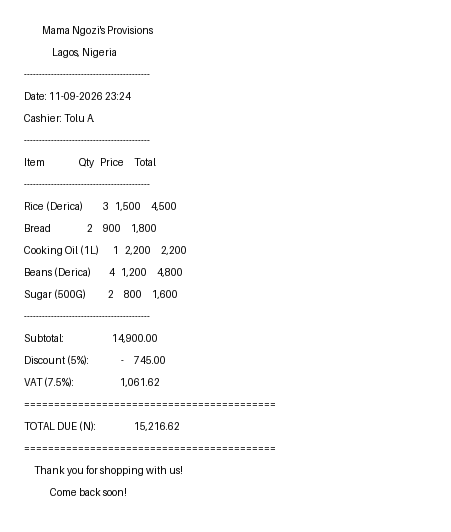

In [5]:
# ============================================================
# STEP 5: SAVE RECEIPT AS AN IMAGE
# ============================================================
from PIL import Image, ImageDraw, ImageFont

def save_receipt_as_image(receipt_text, filename="receipt.png"):
    """
    Render a plain-text receipt onto a white image and save it as a PNG.

    Parameters
    ----------
    receipt_text : str
        The full receipt string, e.g. from generate_receipt().
    filename : str
        Where to save the image file.

    Returns
    -------
    str : the filename the image was saved to.
    """
    # A monospaced font keeps our carefully-aligned columns lined up visually
    font_path = "/usr/share/fonts/truetype/dejavu/DejaVuSansMono.ttf"
    font_size = 16
    try:
        font = ImageFont.truetype(font_path, font_size)
    except OSError:
        # Fallback in case the font file isn't available on some systems
        font = ImageFont.load_default()

    lines = receipt_text.split("\n")
    line_height = font_size + 6
    padding = 24

    # Estimate how wide the image needs to be from the longest line
    longest_line = max(lines, key=len)
    char_width = font_size * 0.6  # rough estimate for a monospace font
    canvas_width = int(padding * 2 + len(longest_line) * char_width)
    canvas_height = padding * 2 + line_height * len(lines)

    # Create a blank white canvas and get a "pen" to draw with
    img = Image.new("RGB", (canvas_width, canvas_height), color="white")
    draw = ImageDraw.Draw(img)

    y = padding
    for line in lines:
        draw.text((padding, y), line, fill="black", font=font)
        y += line_height  # move the "pen" down for the next line

    img.save(filename)
    print(f"Receipt saved as image: {filename}")
    return filename


receipt_image_path = save_receipt_as_image(receipt_text, filename="quickbasket_receipt.png")

# Display the saved receipt image directly in the notebook
from IPython.display import Image as IPyImage
IPyImage(filename=receipt_image_path)


## Summary & Ideas to Extend This Project

| Step | What we built | Core Python concept |
|---|---|---|
| 1 | `cart` dictionary + `add_item()`/`remove_item()` | dictionaries, functions |
| 2 | `collect_items_interactively()` / `load_demo_items()` | `input()`, loops, `try`/`except` |
| 3 | `calculate_subtotal()`, `apply_discount()`, `apply_tax()`, `calculate_totals()` | functions, default arguments, generator expressions |
| 4 | `generate_receipt()` | f-strings, string formatting/alignment |
| 5 | `save_receipt_as_image()` | the Pillow (`PIL`) image library |

**Where you could take this next**, if you wanted to make it a real product:

- **Persist sales**: write each `cart`/`totals` to a CSV file (with the
  `csv` module) or a small SQLite database so the shop keeps a sales history.
- **Barcode/SKU lookup**: replace typed item names with a lookup dictionary
  of known products and prices.
- **Multiple payment methods**: add a `payment_method` field and split
  totals by cash/card/transfer for daily reconciliation.
- **A simple GUI**: wrap these same functions in `tkinter` so a cashier
  clicks buttons instead of typing in a notebook/terminal.
- **Multi-currency support**: parameterise the currency symbol instead of
  hardcoding "N"/"₦" for retailers outside Nigeria.

This notebook intentionally keeps every function small and focused, so each
piece (input, maths, formatting, image export) can be swapped out or
upgraded independently as the app grows.
